In [1]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt 
%matplotlib inline 

In [2]:
words=open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocab of characters and mapping to/from integers
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi["."]=0
itos={i:s for s,i in stoi.items()}
vocab_size=len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# building the dataset 
block_size=3 #context length: how many characters do we take to predict the next one?

def build_datasets(words):
    X,Y = [],[]
    for w in words:
        context=[0] * block_size
        for ch in w + "." :
            ix= stoi[ch]
            X.append(context)
            Y.append(ix)
            context= context[1:]+ [ix] # crop and append

    X= torch.tensor(X)
    Y= torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y

import random 
random.seed(42)

random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))

Xtr, Ytr= build_datasets(words[:n1]) # 80%
Xdev,Ydev=build_datasets(words[n1:n2]) # 10%
Xte,Yte=build_datasets(words[n2:]) # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# MLP revisited 
n_embd=10 #the dimensionality of the character embedding vectors 
n_hidden =200# the number of neurons in the hidden layer of the MLP

g=torch.Generator().manual_seed(2147483647) # for reproducibility
C= torch.randn((vocab_size,n_embd),    generator=g)
W1=torch.randn((n_embd* block_size,n_hidden),generator=g) * (5/3)/((n_embd* block_size)**0.5) #*0.2
# b1= torch.randn(n_hidden,              generator=g) * 0.01
W2= torch.randn((n_hidden,vocab_size), generator=g) * 0.01
b2=torch.randn(vocab_size,             generator=g) * 0

# BatchNorm Parameters 
bngain=torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))
bnmean_running = torch.zeros((1,n_hidden))
bnstd_running=torch.ones((1,n_hidden))

parameters =[C,W1,W2,b2,bngain,bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total 

for p in parameters:
    p.requires_grad= True

12097


tensor(0.0022) tensor(0.9947)
tensor(0.0006) tensor(0.9636)


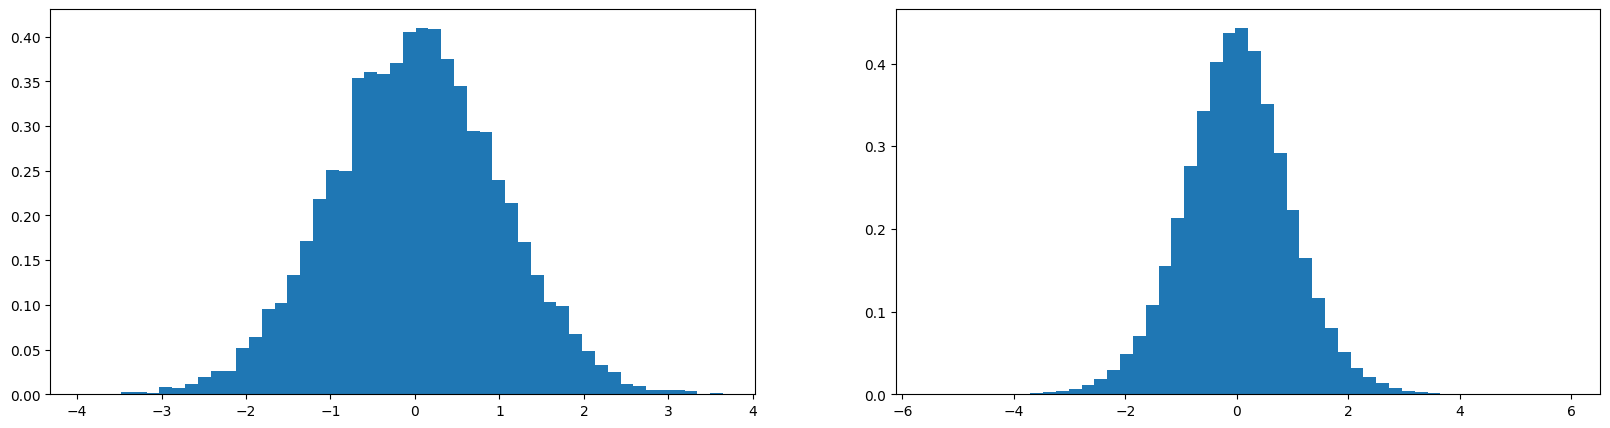

In [7]:
x= torch.randn(1000,10)
w = torch.randn(10,200) / 10**0.5
y= x @ w
print(x.mean(),x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50,density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(),50,density=True);

In [8]:
max_steps = 200000
batch_size=32
lossi=[]
for i in range(max_steps):
    #minibatch construct 
    ix=torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb,Yb =Xtr[ix],Ytr[ix] # batch X,Y

    # foward pass
    emb = C[Xb] #embed the characters into vectors 
    embcat= emb.view(emb.shape[0],-1)
    # linear layer
    hpreact=embcat @ W1 #+ b1 # hidden layer pre-activation

    # BatchNorm Layer
    # ----------------------------------------------------------

    bnmeani=hpreact.mean(0,keepdim=True)
    bnstdi=hpreact.std(0,keepdim=True)
    hpreact= bngain * (hpreact - bnmeani)/ bnstdi + bnbias

    with torch.no_grad():
        bnmean_running=0.999 * bnmean_running + 0.001*bnmeani
        bnstd_running=0.999 * bnstd_running + 0.001*bnstdi
    #-------------------------------------------------------------
    # Non-linearlity  
    h = torch.tanh(hpreact) # hidden layer 
    logits = h @ W2 + b2 # output layer 
    loss = F.cross_entropy(logits,Yb)
    for p in parameters:
        p.grad=None
    loss.backward()

    # update
    lr =0.1 if i< 100000 else 0.01 # step learning rate decay 
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 ==0: # prints every once in a while 
        print(f"{i:7d}/{max_steps:7d}: {loss.item():4f}")
    lossi.append(loss.log10().item())
    # break 

      0/ 200000: 3.323863
  10000/ 200000: 2.032162
  20000/ 200000: 2.567518
  30000/ 200000: 2.012536
  40000/ 200000: 2.244633
  50000/ 200000: 1.889742
  60000/ 200000: 2.078540
  70000/ 200000: 2.368099
  80000/ 200000: 2.291824
  90000/ 200000: 2.023811
 100000/ 200000: 2.367295
 110000/ 200000: 2.313225
 120000/ 200000: 1.641352
 130000/ 200000: 1.931116
 140000/ 200000: 2.223130
 150000/ 200000: 2.002746
 160000/ 200000: 2.099655
 170000/ 200000: 2.494890
 180000/ 200000: 2.019850
 190000/ 200000: 2.170715


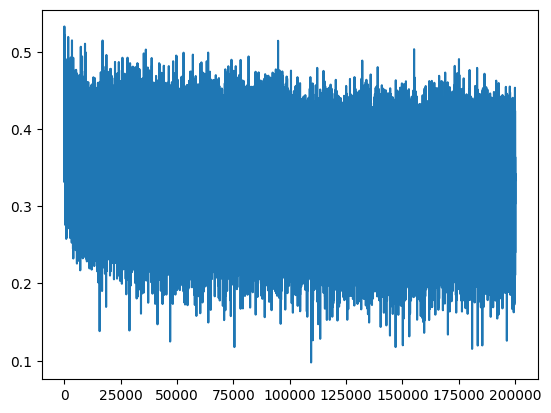

In [9]:
plt.plot(lossi)

In [10]:
# calibrate the batch norm at the end of the training 

with torch.no_grad():
    # pass the training set through
    emb=C[Xtr]
    embcat=emb.view(emb.shape[0],-1)
    hpreact=embcat @ W1 
    # measure the mean/std over the entire training set 
    bnmean = hpreact.mean(0,keepdim=True)
    bnstd=hpreact.std(0, keepdim=True)

In [11]:
bnmean

tensor([[-2.3948,  0.3696, -1.2718,  1.2949,  0.9555,  0.9955,  1.5502, -1.9208,
          1.1124,  1.2444, -1.8118, -2.7730,  0.0738, -0.6075,  0.4335, -0.6823,
          0.7747, -2.1883, -0.1999,  1.5907, -0.8760,  0.0857, -0.2508,  0.4101,
          1.0317,  1.6305,  1.1979,  0.9556,  0.3583,  1.9510, -0.0681, -1.2067,
         -0.1050, -0.2660, -0.4748, -1.4983, -2.6133,  0.0533, -0.0121,  0.6010,
         -0.2272, -0.8899, -0.2851, -0.1833,  0.6507,  0.8990,  1.5831, -0.3836,
          1.9892,  1.0677,  1.7157, -0.7880,  2.0549,  0.3595,  0.5519, -1.9214,
         -0.0325,  0.7197,  0.8938, -0.7950, -0.6654,  0.9819,  0.4983,  0.2976,
          1.1429,  1.6462, -1.3212,  2.4308, -0.5223,  0.4782, -1.0088,  0.2362,
          1.0452, -1.5624, -3.0715,  0.6018,  0.7532, -0.0513,  0.4650,  0.7593,
          0.2517,  1.2639,  1.4016,  0.5572, -0.2063, -0.0653, -1.3350,  0.5009,
          0.1291, -0.4667, -0.3977,  1.4659, -1.1291, -0.8739, -0.9940,  0.2943,
         -0.3024,  0.1405,  

In [12]:
bnmean_running

tensor([[-2.4073e+00,  3.7330e-01, -1.2681e+00,  1.2967e+00,  9.6880e-01,
          9.8373e-01,  1.5421e+00, -1.9247e+00,  1.1060e+00,  1.2247e+00,
         -1.8296e+00, -2.7717e+00,  7.1380e-02, -6.1822e-01,  4.3363e-01,
         -6.6872e-01,  7.7062e-01, -2.1880e+00, -2.1888e-01,  1.5707e+00,
         -8.6627e-01,  1.0769e-01, -2.3913e-01,  4.1437e-01,  1.0355e+00,
          1.6324e+00,  1.1980e+00,  9.5800e-01,  3.5300e-01,  1.9479e+00,
         -8.0373e-02, -1.2021e+00, -9.8021e-02, -2.6651e-01, -4.7075e-01,
         -1.4911e+00, -2.6119e+00,  4.6969e-02, -3.0780e-04,  6.0433e-01,
         -2.3633e-01, -9.1244e-01, -2.8295e-01, -1.7835e-01,  6.5023e-01,
          9.0388e-01,  1.5864e+00, -3.9491e-01,  1.9726e+00,  1.0563e+00,
          1.7167e+00, -7.9531e-01,  2.0450e+00,  3.5585e-01,  5.4983e-01,
         -1.9198e+00, -3.1742e-02,  7.1273e-01,  9.0174e-01, -7.9929e-01,
         -6.7666e-01,  9.6929e-01,  4.8909e-01,  2.9599e-01,  1.1424e+00,
          1.6292e+00, -1.3297e+00,  2.

In [13]:
@torch.no_grad() # this decorator disables gradient tracking 
def split_loss(split):
    x,y ={
        "train": (Xtr,Ytr),
        "val": (Xdev,Ydev),
        "test": (Xte,Yte),
    }[split]
    emb=C[x] # (N, block_size, n_embd)
    embcat=emb.view(emb.shape[0],-1) # concat into (N, block_size * n_embd)
    hpreact= embcat @ W1 #+b1 #hidden layer pre-activation 
    # hpreact= bngain * (hpreact - hpreact.mean(0,keepdim=True))/ hpreact.std(0,keepdim=True) + bnbias
    hpreact= bngain * (hpreact - bnmean_running)/ bnstd_running + bnbias
    h = torch.tanh(hpreact) #(N,n_hidden)
    logits=h @ W2 + b2 #(N,vocab_size)
    loss=F.cross_entropy(logits, y)
    print(split,loss.item())

split_loss('train')
split_loss('val')

train 2.0674145221710205
val 2.1056840419769287


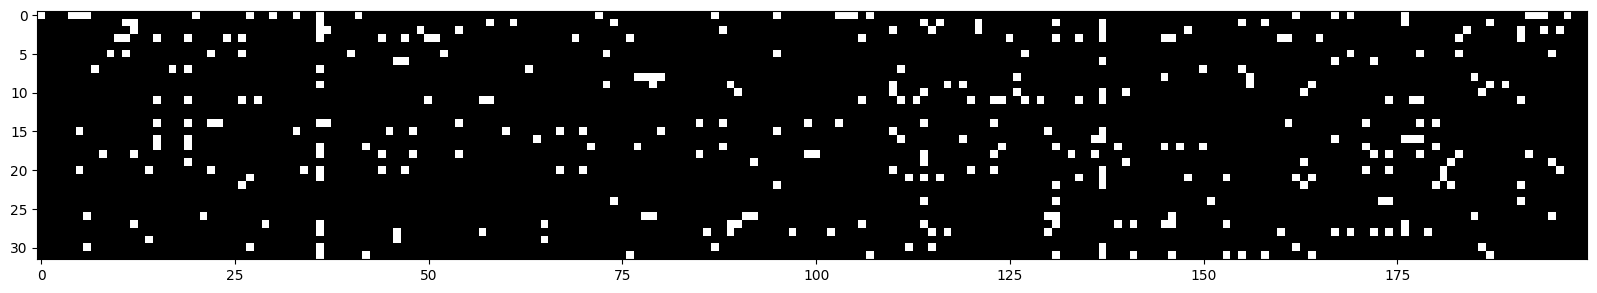

In [14]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap="gray",interpolation="nearest")

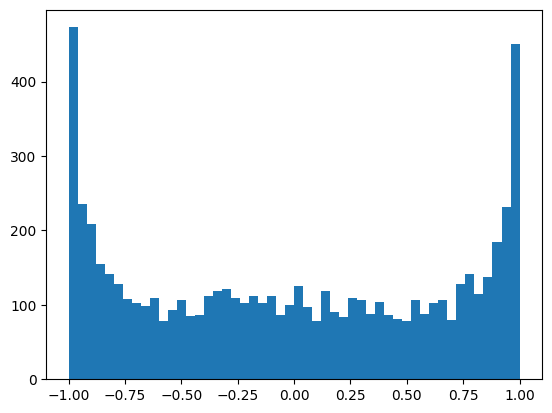

In [15]:
plt.hist(h.view(-1).tolist(),50);

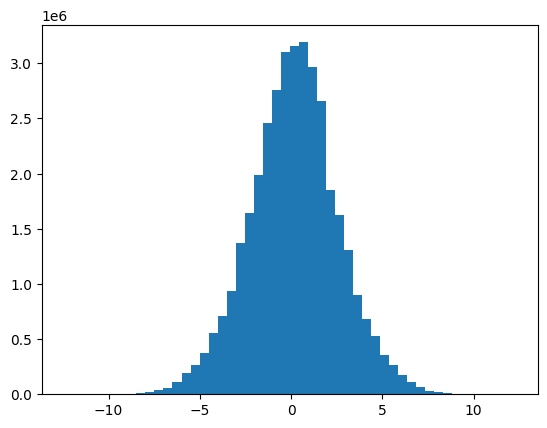

In [16]:
plt.hist(hpreact.view(-1).tolist(),50);

In [17]:
logits[0]

tensor([ 2.2577, -0.0113, -0.4766, -0.3466,  0.5578,  1.6290, -1.2720, -0.3059,
        -1.2959,  0.4393, -1.7247, -0.4591,  1.9454,  1.1694,  0.3051, -1.2232,
        -1.0613, -1.0430, -0.4436,  1.8818,  1.1456, -1.2942,  1.0270, -0.9909,
        -0.2187,  0.4686, -0.4437], grad_fn=<SelectBackward0>)

In [18]:
# 4 dimensional example of the issue 
# logits = torch.tensor([0.0,0.0,0.0,0.0])
logits =torch.randn(4)*100
probs=torch.softmax(logits,dim=0)
loss = -probs[2].log()
logits,probs,loss

(tensor([179.8282, 309.8696, -64.3784, -72.5969]),
 tensor([0., 1., 0., 0.]),
 tensor(inf))

In [19]:
# ideal loss 
-torch.tensor(1/27).log()

tensor(3.2958)

In [20]:
#sample from the model
g=torch.Generator().manual_seed(2147483647+10)
for _ in range(20):
    out=[]
    context=[0] * block_size #initialize with all....
    while True:
        # foward pass the neural net
        emb=C[torch.tensor([context])] # (1, block_size,n_embd)
        h= torch.tanh(emb.view(1,-1) @ W1 )#+ b1)
        logits = h @ W2 + b2
        probs= F.softmax(logits, dim=1)
        # sample from the distribution 
        ix=torch.multinomial(probs, num_samples=1,generator=g).item()
        #shift the context window and track the samples 
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token ,break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out)) # decode and print the generated word 

cathlifatubhl.
shkirrsthlitslestadsh.
jazhmirfardsahmiqueliz.
qumaritzieiirdg.
leggyufbmghziriqustzishlistan.
vabiusstell.
diarisix.
khegzifsabbel.
zaiirsgyasluysfaadhlanyivariksyah.
maboubzettr.
jesiahasdannakphladlummygotberksiaghubniq.
qlylianaysh.
xeinahqueld.
bldn.
tdy.
madthgb.
sphlynanyasislytte.
conzabbuljadak.
khlesdanikosmuseff.
kyaq.


In [21]:
#let's train a deeper network

class Linear:
    def __init__(self, fan_in, fan_out,bias=True):
        self.weight=torch.randn((fan_in,fan_out), generator=g)/fan_in**0.5
        self.bias=torch.zeros(fan_out) if bias else None

    def __call__(self,x):
        self.out=x@ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    def parameters(self):
        return [self.weight]+([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self,dim,eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum=momentum
        self.training=True
        #parameters(trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta=torch.zeros(dim)
        # buffers (trained with a running 'momentum update)
        self.running_mean= torch.zeros(dim)
        self.running_var=torch.ones(dim)
    
    def __call__(self,x):
        # calculate the foward pass
        if self.training:
            xmean=x.mean(0, keepdim=True) # batch mean 
            xvar=x.var(0,keepdim=True,unbiased=True) # batch variance
        else:
            xmean=self.running_mean
            xvar=self.running_var
        xhat=(x-xmean)/torch.sqrt(xvar+self.eps) #normalize to unit variance
        self.out=self.gamma*xhat+ self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean=(1-self.momentum) * self.running_mean+self.momentum * xmean
                self.running_var=(1-self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self,x):
        self.out=torch.tanh(x)
        return self.out 
    def parameters(self):
        return []

n_embed=10 # dimensionality of the character embedding vectors
n_hidden =100 # the number of neurons in the hidden layer of the MLP
g= torch.Generator().manual_seed(2147483647) # for productivity

C= torch.randn((vocab_size,n_embd),         generator=g)
layers=[
    Linear(n_embd* block_size,n_hidden), Tanh(),
    Linear(         n_hidden, n_hidden), Tanh(),
    Linear(         n_hidden, n_hidden), Tanh(),
    Linear(         n_hidden, n_hidden), Tanh(),
    Linear(         n_hidden, n_hidden), Tanh(),
    Linear(         n_hidden, vocab_size), 
]
with torch.no_grad():
    #last layer: make less confident
    layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3
        
    
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters )) #number of parameters in total 
for p in parameters:
    p.requires_grad = True


46497


In [22]:
max_steps = 200000
batch_size=32
lossi = []
ud =[]

for i in range(max_steps):

    # minibatch constryct 
    ix= torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb =Xtr[ix], Ytr[ix] # batch X, Y

    # foward pass
    emb= C[Xb] # embed the characters into vectors 
    x= emb.view (emb.shape[0], -1) # concatenate the vectors 
    for layer in layers:
        x= layer(x)
    loss = F.cross_entropy(x, Yb) # loss function 

    # backward pass 
    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad=None
    loss.backward()

    # update
    lr= 0.1 if i < 100000 else 0.01 # step learning rate decay 
    for p in parameters:
        p.data += -lr * p.grad

    # track stats 
    if i % 1000 == 0: # print every once in a while 
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([(lr*p.grad.std()/ p.data.std()).log10().item() for p in parameters])

    if i>=1000:
        break # AFTER_DEBUG: would take out obviously to run full optimization 



      0/ 200000: 3.2962
   1000/ 200000: 2.2701


layer 1 (      Tanh): mean -0.04, std 0.76, saturated: 21.97%
layer 3 (      Tanh): mean -0.01, std 0.72, saturated: 11.00%
layer 5 (      Tanh): mean +0.01, std 0.73, saturated: 13.00%
layer 7 (      Tanh): mean -0.05, std 0.73, saturated: 13.34%
layer 9 (      Tanh): mean +0.00, std 0.72, saturated: 10.53%


C:\Users\Admin\AppData\Local\Temp\ipykernel_15012\2542392889.py:7: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__,t.mean(), t.std(), (t.abs() >0.97).float().mean()*100))


Text(0.5, 1.0, 'activation distribution')

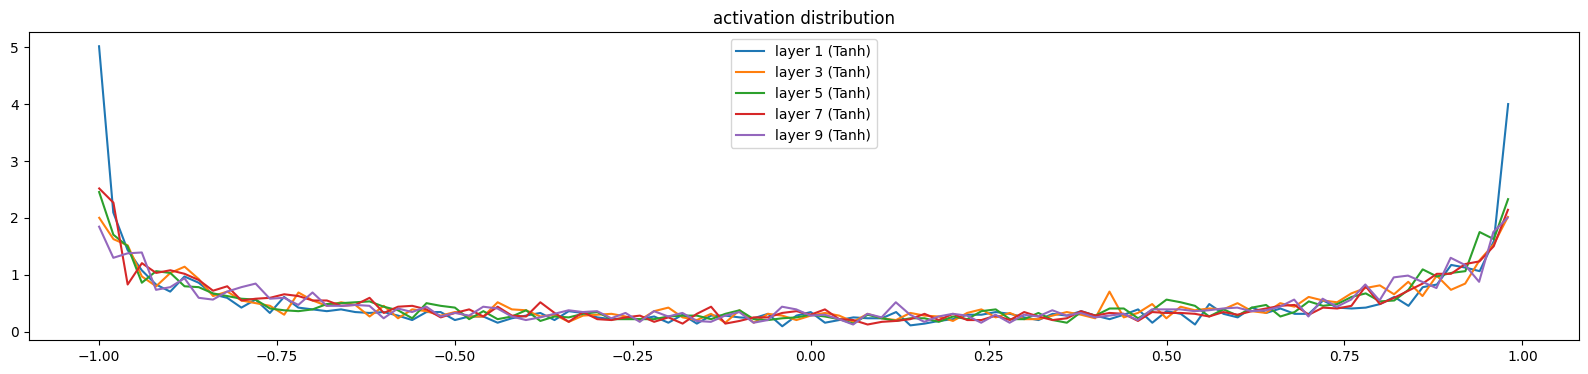

In [23]:
# visualize histograms
plt.figure(figsize=(20,4)) # Width and height of the plot 
legends=[]
for i , layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t= layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__,t.mean(), t.std(), (t.abs() >0.97).float().mean()*100))
        hy,hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(),hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('activation distribution')


layer 1 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 3 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 7 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 9 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%


Text(0.5, 1.0, 'activation distribution')

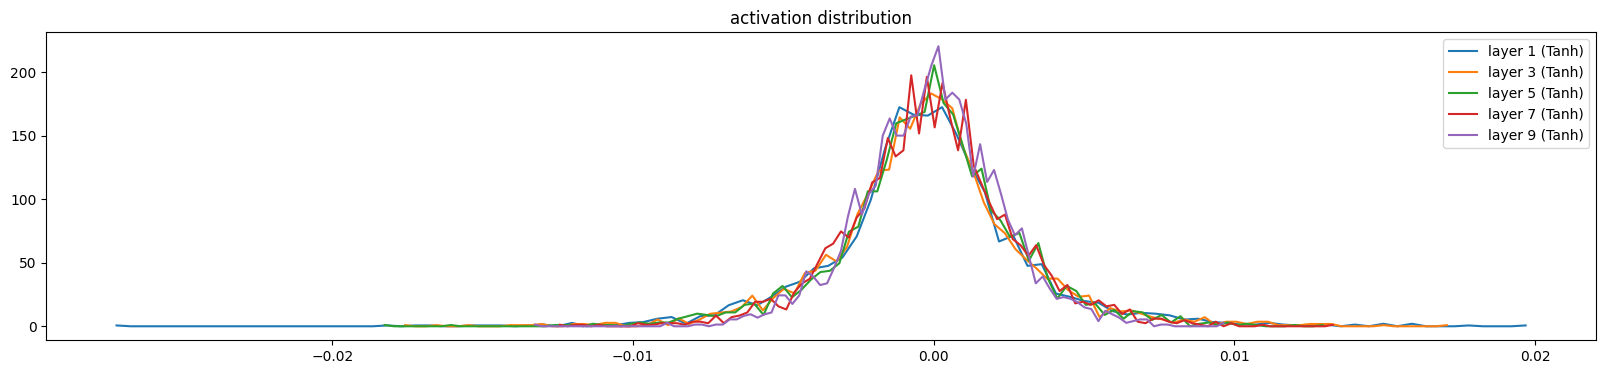

In [24]:
# visualize histograms 
plt.figure(figsize=(20,4)) # Width and height of the plot 
legends=[]
for i , layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t= layer.out.grad
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__,t.mean(), t.std(), (t.abs() >0.97).float().mean()*100))
        hy,hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(),hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('activation distribution')


weight   (27, 10) | mean +0.000980 | std 1.189170e-02 | grad:data ratio 1.189149e-02
weight  (30, 100) | mean +0.000118 | std 1.005290e-02 | grad:data ratio 3.214555e-02
weight (100, 100) | mean +0.000033 | std 7.821211e-03 | grad:data ratio 4.653361e-02
weight (100, 100) | mean -0.000107 | std 6.655620e-03 | grad:data ratio 3.925851e-02
weight (100, 100) | mean -0.000017 | std 6.086040e-03 | grad:data ratio 3.605767e-02
weight (100, 100) | mean -0.000077 | std 5.075620e-03 | grad:data ratio 3.015269e-02
weight  (100, 27) | mean -0.000000 | std 2.056585e-02 | grad:data ratio 2.909911e-01


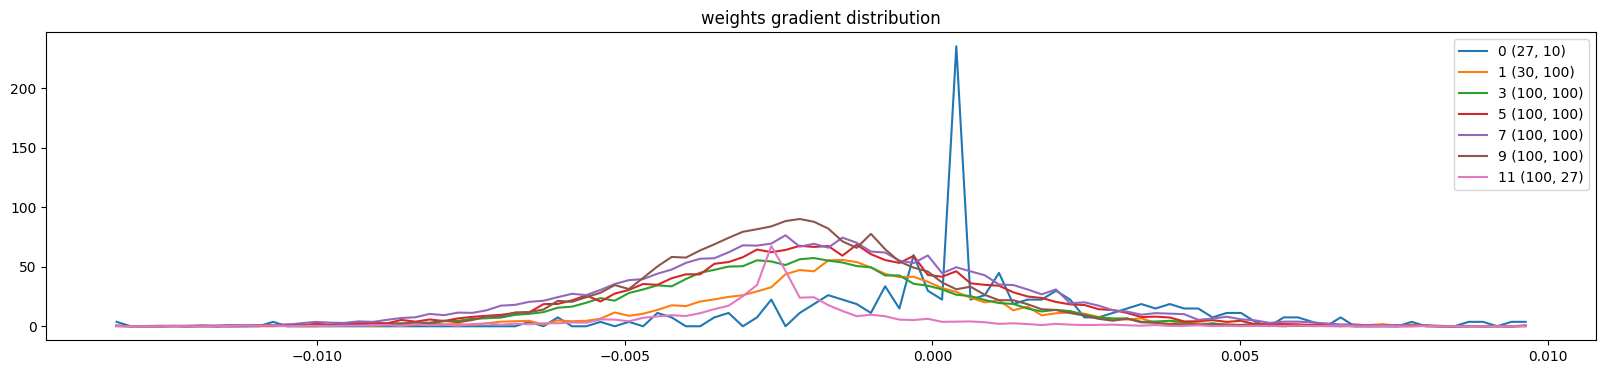

In [27]:
# visualize histograms
plt.figure(figsize=(20,4)) # width and height of the plot
legends=[]
for i, p in enumerate(parameters):
    t= p.grad
    if p.ndim==2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape),t.mean(),t.std(), t.std()/p.std()))
        hy,hz=torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(),hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title("weights gradient distribution");


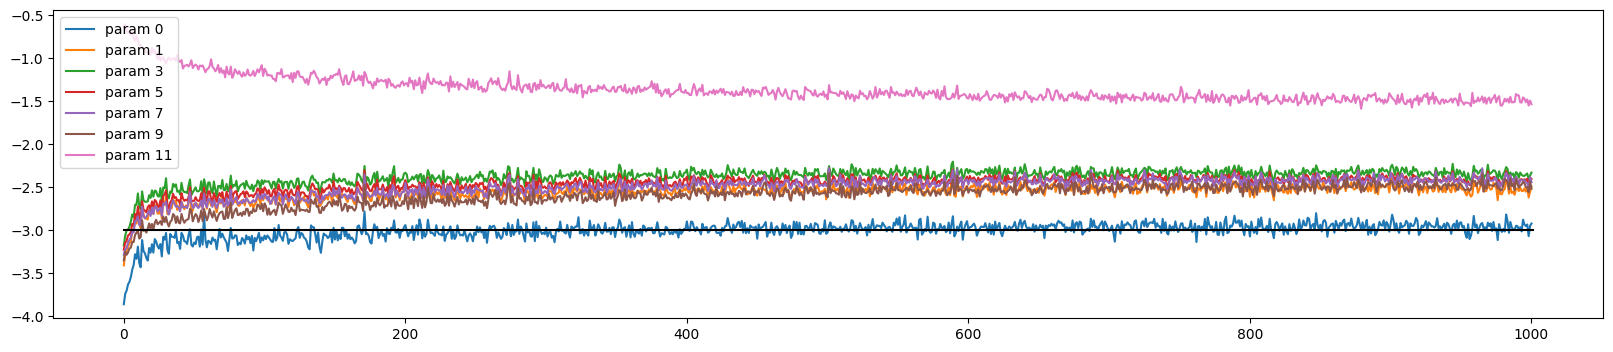

In [ ]:
plt.figure(figsize=(20,4))
legends=[]
for i,p in enumerate(parameters):
    if p.ndim==2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3,-3], 'k') # these ratios should be ~1e-3, indicate on plot 
plt.legend(legends);

# NB if the parameters go below negative 3 then means they are not training fats enough , the -3 comes form e-3